In [ ]:
pip install tensorflow

  Using cached tensorflow-2.20.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-6.33.1-cp39-abi3-manylinux2014_x86_64.whl.metadata (593 bytes)
  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, Embedding, LSTM, Input
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

2025-11-24 15:36:52.455907: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 15:36:52.471048: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-24 15:36:52.797814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-24 15:36:57.670043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [4]:
df = pd.read_csv('Final_News_DF_Labeled_ExamDataset.csv')
df.head()

,LABEL,according,agency,ahead,alabama,amazon,america,american,announced,appeared,...,wolverines,women,work,working,world,wrote,year,years,york,young
0,politics,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,politics,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,politics,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,politics,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,politics,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values    

In [11]:
y

array(['politics', 'politics', 'politics', ..., 'science', 'science',
       'science'], dtype=object)

In [12]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
y_cat = to_categorical(y_enc, num_classes=3)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_cat, random_state=42
)

In [16]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1194, 300)
X_test shape: (299, 300)


In [17]:
# ANN Model

ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
ann.summary()

history_ann = ann.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

2025-11-24 15:42:39.275220: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       154,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,163 (860.01 KB)

 Trainable params: 220,163 (860.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4795 - loss: 1.0021 - val_accuracy: 0.6833 - val_loss: 0.9213
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7104 - loss: 0.7556 - val_accuracy: 0.7250 - val_loss: 0.7095
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8073 - loss: 0.5260 - val_accuracy: 0.7417 - val_loss: 0.6526
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8389 - loss: 0.4076 - val_accuracy: 0.7250 - val_loss: 0.6792
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8650 - loss: 0.3519 - val_accuracy: 0.7500 - val_loss: 0.7116
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8855 - loss: 0.3046 - val_accuracy: 0.7333 - val_loss: 0.7445
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9004 - loss: 0.2538 - val_accuracy: 0.7333 - val_loss: 0.7726
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9088 - loss: 0.2432 - val_accuracy: 0.7167 - v

In [18]:
# CNN Model

X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]

cnn = Sequential([
    Input(shape=(X_train_cnn.shape[1], 1)),
    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(3, activation='softmax')
])

cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 300, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 150, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 150, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 75, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,228,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,254,403 (4.79 MB)

 Trainable params: 1,254,403 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.5912 - loss: 0.8495 - val_accuracy: 0.6833 - val_loss: 0.8037
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.7505 - loss: 0.6090 - val_accuracy: 0.7500 - val_loss: 0.7302
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7989 - loss: 0.4773 - val_accuracy: 0.7417 - val_loss: 0.7020
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8482 - loss: 0.3835 - val_accuracy: 0.7333 - val_loss: 0.7662
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8696 - loss: 0.3065 - val_accuracy: 0.7333 - val_loss: 0.8377
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9032 - loss: 0.2442 - val_accuracy: 0.7583 - val_loss: 0.8552
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.9227 - loss: 0.1980 - val_accuracy: 0.7417 - val_loss: 1.0709
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9246 - loss: 0.1817 - val_accuracy: 0.7250 - v

In [19]:
# LSTM Model

X_train_lstm = X_train[..., np.newaxis]
X_test_lstm = X_test[..., np.newaxis]

lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], 1)),
    LSTM(128),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm.summary()

history_lstm = lstm.fit(
    X_train_lstm, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,011 (293.01 KB)

 Trainable params: 75,011 (293.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 338ms/step - accuracy: 0.3669 - loss: 1.0950 - val_accuracy: 0.2750 - val_loss: 1.7251
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.3929 - loss: 1.1034 - val_accuracy: 0.4333 - val_loss: 1.0902
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - accuracy: 0.4376 - loss: 1.0902 - val_accuracy: 0.4417 - val_loss: 1.0861
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 290ms/step - accuracy: 0.4264 - loss: 1.0914 - val_accuracy: 0.4583 - val_loss: 1.0759
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.4358 - loss: 1.0816 - val_accuracy: 0.4667 - val_loss: 1.0678
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step - accuracy: 0.4693 - loss: 1.0530 - val_accuracy: 0.4417 - val_loss: 1.0629
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 240ms/step - accuracy: 0.4842 - loss: 1.0398 - val_accuracy: 0.4833 - val_loss: 1.0562
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.4544 - loss: 1.0505 - val_accurac

In [20]:
def eval_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = np.argmax(y_test, axis=1)
    
    print(f"--- {model_name} ---")
    print("Classification Report:")
    print(classification_report(y_true, y_pred_classes, target_names=le.classes_))
    
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
--- ANN ---
Classification Report:
              precision    recall  f1-score   support

    football       0.85      0.82      0.83       100
    politics       0.76      0.69      0.72       100
     science       0.68      0.76      0.71        99

    accuracy                           0.76       299
   macro avg       0.76      0.76      0.76       299
weighted avg       0.76      0.76      0.76       299



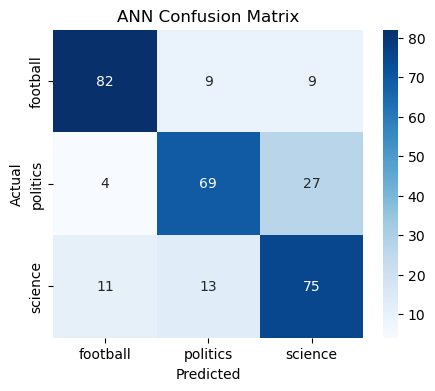

In [21]:
eval_model(ann, X_test, y_test, "ANN")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
--- CNN ---
Classification Report:
              precision    recall  f1-score   support

    football       0.83      0.81      0.82       100
    politics       0.71      0.60      0.65       100
     science       0.65      0.76      0.70        99

    accuracy                           0.72       299
   macro avg       0.73      0.72      0.72       299
weighted avg       0.73      0.72      0.72       299



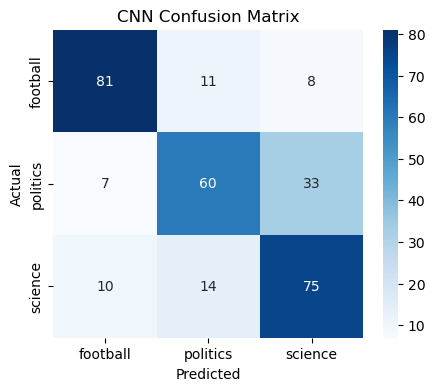

In [22]:
eval_model(cnn, X_test_cnn, y_test, "CNN")

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step
--- LSTM ---
Classification Report:
              precision    recall  f1-score   support

    football       0.67      0.33      0.44       100
    politics       0.65      0.32      0.43       100
     science       0.39      0.79      0.52        99

    accuracy                           0.48       299
   macro avg       0.57      0.48      0.46       299
weighted avg       0.57      0.48      0.46       299



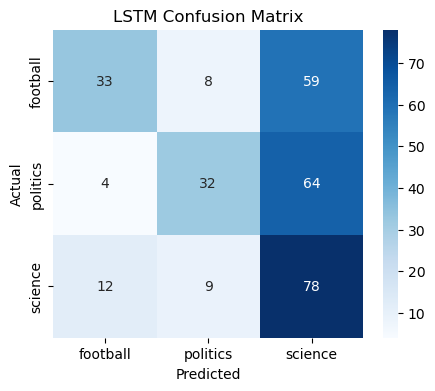

In [23]:
eval_model(lstm, X_test_lstm, y_test, "LSTM")